In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# CPU

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import os

# Parameter to change
data_folder_path = "/content/drive/MyDrive/Thesis"  # The folder path which inluding aef and s2 data
save_dir = "/content/drive/MyDrive/Thesis/"    # The folder path where models have to save
grid_search = True
data = "AEF"  #S2 for sentinal-2 data

# file path preperation
file_name = f"full_shuffled_{data.lower()}_data.csv"
file_path = os.path.join(data_folder_path, file_name)

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

# AEF date column written AEF_Date
# S2 date column written S2_Date
date_column_name = f"{data}_Date"

print("\nData preparation...")
df.drop(columns=["height", "stock_per_ha", "basal_area", "poly_id", date_column_name], axis=1, inplace=True)

y = df["age"] - 1
X = df.drop(columns="age", axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

plt.figure(figsize=(8, 4))
y_train.plot.hist()
plt.title("Distribution of y_train")
plt.show()

if grid_search:
    print("\nGrid search training...")

    # XGBClassifier
    pipeline_xgb = ImbPipeline([
        ("oversample", RandomOverSampler(sampling_strategy="auto")),
        ("classifier", XGBClassifier(objective='multi:softprob', eval_metric='mlogloss'))
    ])

    param_grid_xgb = {
        'classifier__n_estimators': [100, 500, 1000],
        'classifier__max_depth': [5, 7, 9],
        'classifier__learning_rate': [0.05, 0.1, 0.01],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }

    grid_search_xgb = GridSearchCV(
        estimator=pipeline_xgb,
        param_grid=param_grid_xgb,
        scoring='f1_macro',
        n_jobs=-1,
        cv=5,
        verbose=1
    )

    print("Training XGBoost GridSearch...")
    grid_search_xgb.fit(X_train, y_train)

    print("Best Parameters XGB: ", grid_search_xgb.best_params_)
    XGBmodel_age = grid_search_xgb.best_estimator_

    # Random Forest
    pipeline_rfc = ImbPipeline([
        ("oversample", RandomOverSampler(sampling_strategy="auto")),
        ('classifier', RandomForestClassifier(n_jobs=-1))
    ])

    param_grid_rfc = {
        'classifier__n_estimators': [100, 500, 1000, 2000],
        'classifier__max_depth': [10, 20, None],
        'classifier__min_samples_split': [2, 5, 7],
        'classifier__max_features': ['sqrt', 'log2', None]
    }

    grid_search_rfc = GridSearchCV(
        estimator=pipeline_rfc,
        param_grid=param_grid_rfc,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=1
    )

    print("Training Random Forest GridSearch...")
    grid_search_rfc.fit(X_train, y_train)

    print("Best Parameters RFC: ", grid_search_rfc.best_params_)
    RFCmodel_age = grid_search_rfc.best_estimator_

else:
    print("\nSimple models training...")
    ros = RandomOverSampler(sampling_strategy='auto')
    X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
    print("Oversampled X train data shape: ", X_resampled.shape)

    XGBmodel_age = XGBClassifier(n_estimators=200, objective='multi:softprob', eval_metric='mlogloss', early_stopping_rounds=50)
    XGBmodel_age.fit(X_resampled, y_resampled, eval_set=[(X_val, y_val)], verbose=False)
    print("XGBoost Training finished")

    RFCmodel_age = RandomForestClassifier(n_estimators=100, n_jobs=-1)
    RFCmodel_age.fit(X_resampled, y_resampled)
    print("Random Forest Training finished")

# Evaluation
print("\nEvaluating models on Test Set...")
xgb_pred = XGBmodel_age.predict(X_test)
rfc_pred = RFCmodel_age.predict(X_test)

print("\nXGBClassifier Classification Report")
print(classification_report(y_test, xgb_pred))

print("\nRandomForestClassifier Classification Report")
print(classification_report(y_test, rfc_pred))

# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("XGBClassifier")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_rfc = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("RandomForestClassifier")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# Save model
xgb_save_path = os.path.join(save_dir, f"{data}XGBmodel_age.joblib")
rfc_save_path = os.path.join(save_dir, f"{data}RFCmodel_age.joblib")

print("Saving models...")
joblib.dump(XGBmodel_age, xgb_save_path)
joblib.dump(RFCmodel_age, rfc_save_path)
print(f"Models saved to {save_dir}")

# GPU

In [2]:
!pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 44.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-cuda-nvcc-cu12
    Found existing installation: nvidia-cuda-nvcc-cu12 12.5.82
    Uninstalling nvidia-cuda-nvcc-cu12-12.5.82:
      Successfully uninstalled nvidia-cuda-nvcc-cu12-12.5.82


Loading data...
Data is loaded

Data preparation...

Datasets are read! X_train shape: (467, 256), X_test shape: (83, 256), X_val shape: (98, 256)


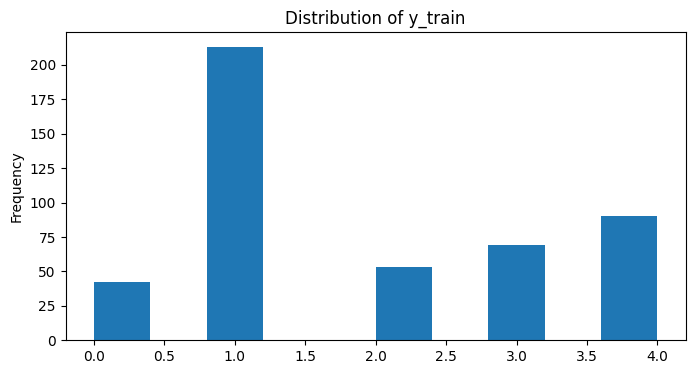


Grid search training...
Training XGBoost GridSearch...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [20:41:36] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Best Parameters XGB:  {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}
Training Random Forest GridSearch...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best Parameters RFC:  {'classifier__max_depth': 10, 'classifier__max_features': 'sqrt', 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}

Evaluating models on Test Set...

XGBClassifier Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.71      0.60      0.65        40
           2       0.27      0.40      0.32        10
           3       0.08      0.11      0.10         9
           4       0.67      0.56      0.61        18

    accuracy                           0.47        83
   macro avg       0.34      0.33      0.33        83
weighted avg       0.53      0.47      0.49        83




/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


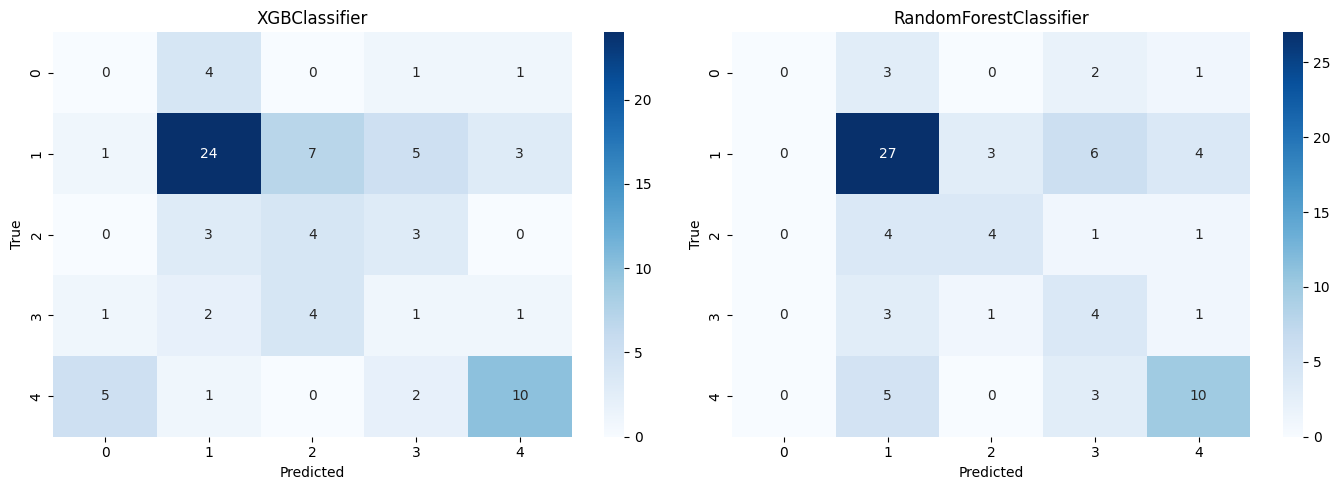

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
import joblib
import os
# cuml libraries
import cuml.accel
cuml.accel.install()
import cupy as cp
# Import the cuML version of Random Forest
from cuml.ensemble import RandomForestClassifier as cuRF


# Parameter to change
data_folder_path = "/content/drive/MyDrive/Thesis"  # The folder path which inluding aef and s2 data
save_dir = "/content/drive/MyDrive/Thesis/"    # The folder path where models have to save
grid_search = True
data = "AEF"  #S2 for sentinal-2 data

# file path preperation
file_name = f"full_shuffled_{data.lower()}_data.csv"
file_path = os.path.join(data_folder_path, file_name)

print("Loading data...")
df = pd.read_csv(file_path)
print("Data is loaded")

# AEF date column written AEF_Date
# S2 date column written S2_Date
date_column_name = f"{data}_Date"

print("\nData preparation...")
df.drop(columns=["height", "stock_per_ha", "basal_area", "poly_id", date_column_name], axis=1, inplace=True)


y = df["age"] - 1
X = df.drop(columns="age", axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.15)

print(f"\nDatasets are read! X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, X_val shape: {X_val.shape}")

plt.figure(figsize=(8, 4))
y_train.plot.hist()
plt.title("Distribution of y_train")
plt.show()

if grid_search:
    print("\nGrid search training...")

    # XGBClassifier
    pipeline_xgb = ImbPipeline([
        ("oversample", RandomOverSampler(sampling_strategy="auto")),
        ("classifier", XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', tree_method='hist', device = "cuda"))
    ])

    param_grid_xgb = {
        'classifier__n_estimators': [100, 500, 1000],
        'classifier__max_depth': [5, 7, 9],
        'classifier__learning_rate': [0.05, 0.1, 0.01],
        'classifier__subsample': [0.8, 1.0],
        'classifier__colsample_bytree': [0.8, 1.0]
    }


    grid_search_xgb = GridSearchCV(
        estimator=pipeline_xgb,
        param_grid=param_grid_xgb,
        scoring='f1_macro',
        n_jobs=1,
        cv=5,
        verbose=1
    )

    print("Training XGBoost GridSearch...")
    grid_search_xgb.fit(X_train, y_train)

    print("Best Parameters XGB: ", grid_search_xgb.best_params_)
    XGBmodel_age = grid_search_xgb.best_estimator_

    # Random Forest
    pipeline_rfc = ImbPipeline([
        ("oversample", RandomOverSampler(sampling_strategy="auto")),
        ('classifier', cuRF())
    ])

    param_grid_rfc = {
        'classifier__n_estimators': [100, 500, 1000, 2000],
        'classifier__max_depth': [10, 20, 30, None],
        'classifier__min_samples_split': [2, 5, 7],
        'classifier__max_features': ['sqrt', 'log2', None]
    }

    grid_search_rfc = GridSearchCV(
        estimator=pipeline_rfc,
        param_grid=param_grid_rfc,
        cv=5,
        scoring='f1_macro',
        n_jobs=1,
        verbose=1
    )

    print("Training Random Forest GridSearch...")
    grid_search_rfc.fit(X_train, y_train)

    print("Best Parameters RFC: ", grid_search_rfc.best_params_)
    RFCmodel_age = grid_search_rfc.best_estimator_

else:
    print("\nSimple models training...")
    ros = RandomOverSampler(sampling_strategy='auto')
    X_resampled, y_resampled = ros.fit_resample(X_train, y_train)
    print("Oversampled X train data shape: ", X_resampled.shape)

    XGBmodel_age = XGBClassifier(n_estimators=200, objective='multi:softprob', eval_metric='mlogloss', tree_method='hist', device = "cuda",  early_stopping_rounds=50)
    XGBmodel_age.fit(X_resampled, y_resampled, eval_set=[(X_val, y_val)], verbose=False)
    print("XGBoost Training finished")

    RFCmodel_age = cuRF(n_estimators = 200)
    RFCmodel_age.fit(X_resampled, y_resampled)
    print("Random Forest Training finished")

# Evaluation
print("\nEvaluating models on Test Set...")
xgb_pred = XGBmodel_age.predict(X_test)
rfc_pred = RFCmodel_age.predict(X_test)

print("\nXGBClassifier Classification Report")
print(classification_report(y_test, xgb_pred))

print("\nRandomForestClassifier Classification Report")
print(classification_report(y_test, rfc_pred))

# Plot Confusion Matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("XGBClassifier")
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

cm_rfc = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title("RandomForestClassifier")
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

# Save model
xgb_save_path = os.path.join(save_dir, f"{data}XGBmodel_age.joblib")
rfc_save_path = os.path.join(save_dir, f"{data}RFCmodel_age.joblib")

print("Saving models...")
joblib.dump(XGBmodel_age, xgb_save_path)
joblib.dump(RFCmodel_age, rfc_save_path)
print(f"Models saved to {save_dir}")